# Consumer Preferences: Indifference Curves and the Budget Line

Goal: understand consumer choice as the interaction between:
- Preferences (indifference curves)
- Constraints (budget constraint)

We consider two goods:
- Good x (horizontal axis)
- Good y (vertical axis)

We use a simple Cobb-Douglas utility function:
U(x,y) = x^alpha y^(1-alpha)

Interpretation:
- Higher alpha -> stronger preference for x relative to y
- Lower alpha -> stronger preference for y relative to x


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def utility(X, Y, alpha=0.5):
    # Cobb-Douglas utility
    return (X**alpha) * (Y**(1 - alpha))

def optimum_bundle(m=100, px=1, py=1, alpha=0.5):
    # Cobb-Douglas optimum
    x_star = alpha * m / px
    y_star = (1 - alpha) * m / py
    return x_star, y_star

def plot_consumer(m=100, px=1, py=1, alpha=0.5,
                  x_max=160, y_max=160,
                  u_levels=(10, 20, 30, 40, 50, 60)):
    # Voila-friendly grid (faster than 500x500)
    x = np.linspace(1e-3, x_max, 200)
    y = np.linspace(1e-3, y_max, 200)
    X, Y = np.meshgrid(x, y)

    # Budget line: y = (m - px*x)/py
    y_budget = (m - px * x) / py

    # Optimal bundle
    x_star, y_star = optimum_bundle(m, px, py, alpha)
    u_star = utility(x_star, y_star, alpha)

    plt.figure(figsize=(7, 5))

    # Indifference curves at fixed utility levels
    cs = plt.contour(X, Y, utility(X, Y, alpha), levels=list(u_levels))
    # Labeling contours is slower; keep off for smooth Voila response
    # plt.clabel(cs, inline=True, fontsize=9)

    # Plot budget line only where visible
    mask = (y_budget >= 0) & (y_budget <= y_max)
    plt.plot(x[mask], y_budget[mask], linewidth=2)

    # Plot optimal point if visible
    if 0 <= x_star <= x_max and 0 <= y_star <= y_max:
        plt.scatter([x_star], [y_star], s=70)

    plt.xlim(0, x_max)
    plt.ylim(0, y_max)
    plt.xlabel("Good x")
    plt.ylabel("Good y")
    plt.title("Indifference Curves (fixed levels) + Budget Line (fixed window)")
    plt.show()

    # Print geometry explicitly (helps non-quant students)
    slope = -px / py
    x_int = m / px
    y_int = m / py
    print(f"m={m}, px={px}, py={py}, alpha={alpha}")
    print(f"Budget line: y = (m/py) - (px/py)x  | slope = {slope:.2f}")
    print(f"Intercepts: x-intercept m/px = {x_int:.2f}, y-intercept m/py = {y_int:.2f}")
    print(f"Optimal bundle: x*={x_star:.2f}, y*={y_star:.2f}, U*={u_star:.2f}")



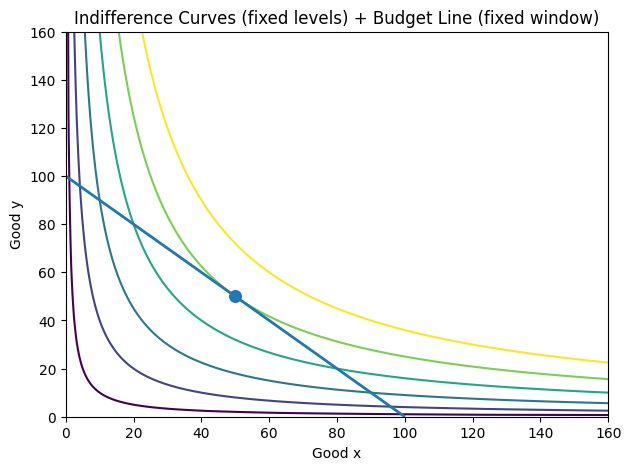

m=100, px=1, py=1, alpha=0.5
Budget line: y = (m/py) - (px/py)x  | slope = -1.00
Intercepts: x-intercept m/px = 100.00, y-intercept m/py = 100.00
Optimal bundle: x*=50.00, y*=50.00, U*=50.00


In [2]:
plot_consumer(m=100, px=1, py=1, alpha=0.5)


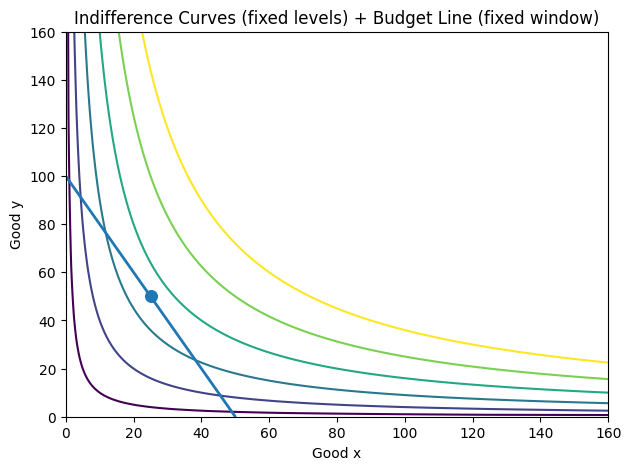

m=100, px=2, py=1, alpha=0.5
Budget line: y = (m/py) - (px/py)x  | slope = -2.00
Intercepts: x-intercept m/px = 50.00, y-intercept m/py = 100.00
Optimal bundle: x*=25.00, y*=50.00, U*=35.36


In [3]:
plot_consumer(m=100, px=2, py=1, alpha=0.5)


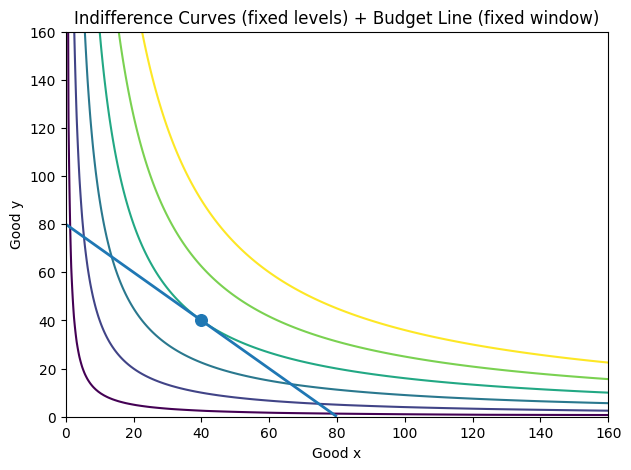

m=80, px=1, py=1, alpha=0.5
Budget line: y = (m/py) - (px/py)x  | slope = -1.00
Intercepts: x-intercept m/px = 80.00, y-intercept m/py = 80.00
Optimal bundle: x*=40.00, y*=40.00, U*=40.00


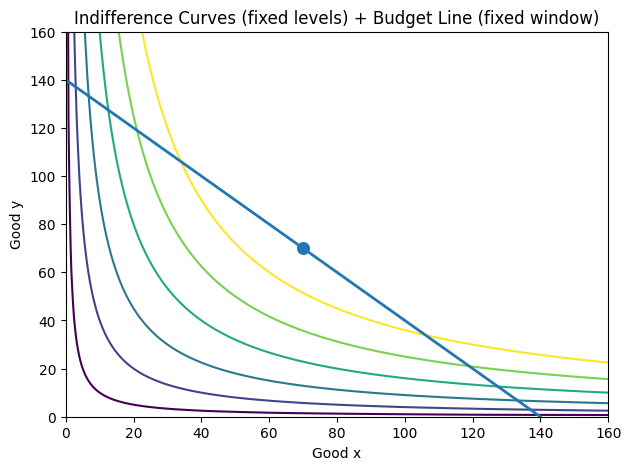

m=140, px=1, py=1, alpha=0.5
Budget line: y = (m/py) - (px/py)x  | slope = -1.00
Intercepts: x-intercept m/px = 140.00, y-intercept m/py = 140.00
Optimal bundle: x*=70.00, y*=70.00, U*=70.00


In [4]:
plot_consumer(m=80, px=1, py=1, alpha=0.5)
plot_consumer(m=140, px=1, py=1, alpha=0.5)


In [5]:

from ipywidgets import interact, FloatSlider, fixed

interact(
    plot_consumer,
    m=FloatSlider(value=100, min=20, max=200, step=10, description="Income m", continuous_update=False),
    px=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description="Price px", continuous_update=False),
    py=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description="Price py", continuous_update=False),
    alpha=FloatSlider(value=0.5, min=0.1, max=0.9, step=0.05, description="alpha", continuous_update=False),
    x_max=FloatSlider(value=160, min=60, max=300, step=10, description="x window", continuous_update=False),
    y_max=FloatSlider(value=160, min=60, max=300, step=10, description="y window", continuous_update=False),
    u_levels=fixed((10, 20, 30, 40, 50, 60)),
);

interactive(children=(FloatSlider(value=100.0, continuous_update=False, description='Income m', max=200.0, min…